# **Proyecto IA**
#**Tercer entrega**

-Nelson Andres Urrea Calvo 2221115\
-Jhon Jairo Velandia Ramirez 2220028\
-Cristian Ferney Rivera González 2234509



# Descripción del dataset:
**Online Learning Engagement Dataset** : https://uci-ics-mlr-prod.aws.uci.edu/dataset/697/p…%2Band%2Bacademic%2Bsuccess?

Este conjunto de datos contiene información que representa la participación y el comportamiento de aprendizaje de los estudiantes en un entorno de educación en línea. Incluye diversas características relacionadas con la demografía estudiantil, los hábitos de estudio, la actividad en la plataforma y el rendimiento académico.




# PROBLEMATICA
El problema abordado en este análisis es la predicción del rendimiento académico y la permanencia estudiantil mediante el uso de técnicas de Machine Learning. A partir de variables relacionadas con el comportamiento del estudiante, como las horas de estudio, la frecuencia de acceso, la participación en actividades, la interacción en la plataforma y el desempeño en evaluaciones, se busca construir un modelo capaz de clasificar a los estudiantes según su resultado académico.
De esta manera, se pretende identificar si un estudiante tiene probabilidad de abandonar sus estudios o de completar su proceso formativo.


## librerias

In [1]:

import os
import numpy as np
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Montar el drive

In [2]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Proyecto/Segundo dataset/data.csv';
df = pd.read_csv(path, sep=';')

Mounted at /content/drive


In [3]:
# Mostrar información básica
print("df shape:", df.shape)
df
print("\nPrimeras filas del df:")
display(df.head())


df shape: (4424, 37)

Primeras filas del df:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

##INFORMACION DE DATOS

## Valores nulos en cada columna

In [5]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


##Valores maximos y minimos de cada columna

In [6]:
df_num = df.select_dtypes(include="number")
resultado = pd.DataFrame({
    "max": df_num.max(),
    "min": df_num.min()
})
for col in df_num.columns:
    print(f"Columna {col}: max={df_num[col].max()}, min={df_num[col].min()}")

Columna Marital status: max=6, min=1
Columna Application mode: max=57, min=1
Columna Application order: max=9, min=0
Columna Course: max=9991, min=33
Columna Daytime/evening attendance	: max=1, min=0
Columna Previous qualification: max=43, min=1
Columna Previous qualification (grade): max=190.0, min=95.0
Columna Nacionality: max=109, min=1
Columna Mother's qualification: max=44, min=1
Columna Father's qualification: max=44, min=1
Columna Mother's occupation: max=194, min=0
Columna Father's occupation: max=195, min=0
Columna Admission grade: max=190.0, min=95.0
Columna Displaced: max=1, min=0
Columna Educational special needs: max=1, min=0
Columna Debtor: max=1, min=0
Columna Tuition fees up to date: max=1, min=0
Columna Gender: max=1, min=0
Columna Scholarship holder: max=1, min=0
Columna Age at enrollment: max=70, min=17
Columna International: max=1, min=0
Columna Curricular units 1st sem (credited): max=20, min=0
Columna Curricular units 1st sem (enrolled): max=26, min=0
Columna Curr

##Variable objetivo

"Dropout" Esta variable representa la deserción de los estudiantes en los cursos a partir de dos posible valores 2, 1 y 0  que significan si el estudiante ingreso, aprovo o abandono el curso respectivamente.

In [7]:
df['Target'] = df['Target'].replace({
    'Graduate': 0,
    'Dropout': 1,
    'Enrolled': 0
})

df['Target'].value_counts()

/tmp/ipykernel_6586/3125378057.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace({


,count
Target,
0,3003
1,1421


In [8]:
#20 variables con más correlación
numeric = df.select_dtypes(include=np.number).columns
cor = df[numeric].corr()
columnas = cor["Target"].sort_values(ascending=False).head(21).index.tolist()

In [9]:
columnas.remove('Target')
columnas

['Age at enrollment',
 'Debtor',
 'Gender',
 'Application mode',
 'Marital status',
 'Curricular units 2nd sem (without evaluations)',
 "Mother's qualification",
 'Curricular units 1st sem (without evaluations)',
 'Previous qualification',
 'Inflation rate',
 "Father's qualification",
 'Unemployment rate',
 'Nacionality',
 'Educational special needs',
 'International',
 "Mother's occupation",
 "Father's occupation",
 'Curricular units 1st sem (credited)',
 'Curricular units 2nd sem (credited)',
 'Course']

In [10]:
X = df[columnas]
y = df['Target']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.metrics import F1Score


2.20.0


In [13]:
model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_nn.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        F1Score(
            average='macro',
            threshold=0.5,
            name='f1_macro'
        )
    ]
)


In [15]:
history = model_nn.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - f1_macro: 0.4289 - loss: 0.5921 - val_f1_macro: 0.4153 - val_loss: 0.5513
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5035 - loss: 0.5422 - val_f1_macro: 0.4366 - val_loss: 0.5518
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5182 - loss: 0.5347 - val_f1_macro: 0.4747 - val_loss: 0.5451
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5273 - loss: 0.5271 - val_f1_macro: 0.4579 - val_loss: 0.5442
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5333 - loss: 0.5231 - val_f1_macro: 0.4630 - val_loss: 0.5426
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5411 - loss: 0.5168 - val_f1_macro: 0.5136 - val_loss: 0.5461
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5449 - loss: 0.5143 - val_f1_macro: 0.4855 - val_loss: 0.5430
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5487 - loss: 0.5099 - val_f1_macro: 0.

In [16]:
test_loss, test_f1 = model_nn.evaluate(
    X_test_scaled,
    y_test
)

print((test_loss, test_f1))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5021 - loss: 0.5398 
(0.5397742986679077, 0.502109706401825)


#MOSTRAR TRAIN Y TEST F1 MACRO

In [17]:
train_loss, train_f1 = model_nn.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

test_loss, test_f1 = model_nn.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\nResultados del Modelo 1:")
print(f"Train F1 Macro: {train_f1:.4f}")
print(f"Test F1 Macro:  {test_f1:.4f}")


Resultados del Modelo 1:
Train F1 Macro: 0.5905
Test F1 Macro:  0.5021


#PREDICCIONES + F1 MODELO 1

In [18]:
# Predicciones probabilísticas
y_pred_prob = model_nn.predict(X_test_scaled)

# Convertir a clases binarias
y_pred = (y_pred_prob > 0.5).astype(int)

# Reporte
print(classification_report(y_test, y_pred))

# F1 Macro Modelo 1
f1_model1 = f1_score(y_test, y_pred, average='macro')

print(f"\nF1 Macro Modelo 1: {f1_model1:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.76      0.88      0.82       601
           1       0.63      0.42      0.50       284

    accuracy                           0.73       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.72      0.73      0.72       885


F1 Macro Modelo 1: 0.6600


#MATRIZ DE CONFUSIÓN

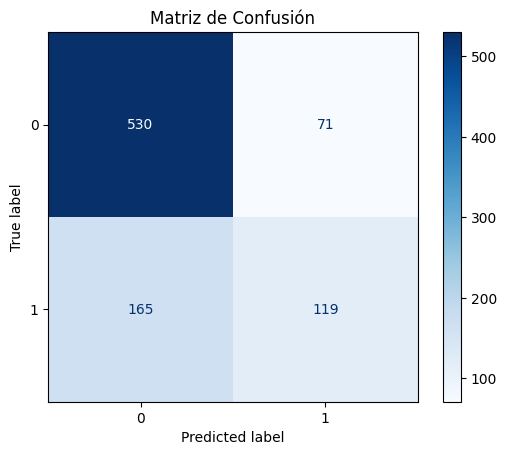

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Matriz de Confusión")
plt.show()

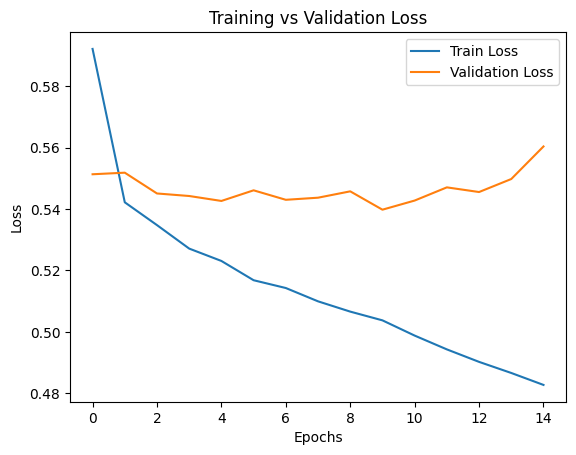

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.title('Training vs Validation Loss')

plt.show()

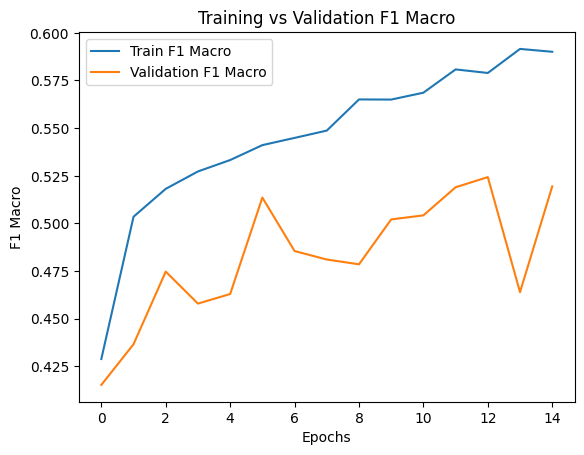

In [21]:
plt.plot(history.history['f1_macro'], label='Train F1 Macro')

plt.plot(history.history['val_f1_macro'], label='Validation F1 Macro')

plt.xlabel('Epochs')

plt.ylabel('F1 Macro')

plt.legend()

plt.title('Training vs Validation F1 Macro')

plt.show()

In [22]:
# ==============================
# SEGUNDO MODELO DE RED NEURONAL
# ==============================

model_nn2 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(20,)),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

model_nn2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        F1Score(
            average='macro',
            threshold=0.5,
            name='f1_macro'
        )
    ]
)

print("\nArquitectura Modelo 2:")
model_nn2.summary()

history2 = model_nn2.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluación
train_loss2, train_f12 = model_nn2.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

test_loss2, test_f12 = model_nn2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\nResultados Modelo 2:")
print(f"Train F1 Macro: {train_f12:.4f}")
print(f"Test F1 Macro:  {test_f12:.4f}")

# Predicciones
y_pred_prob2 = model_nn2.predict(X_test_scaled)

y_pred2 = (y_pred_prob2 > 0.5).astype(int)

# Reporte
print("\nClassification Report Modelo 2:")

print(classification_report(y_test, y_pred2))

# F1 Macro Modelo 2
f1_model2 = f1_score(
    y_test,
    y_pred2,
    average='macro'
)

print(f"\nF1 Macro Modelo 2: {f1_model2:.4f}")


Arquitectura Modelo 2:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_macro: 0.3524 - loss: 0.5939 - val_f1_macro: 0.4010 - val_loss: 0.5551
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.4514 - loss: 0.5558 - val_f1_macro: 0.4792 - val_loss: 0.5479
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.5045 - loss: 0.5469 - val_f1_macro: 0.4842 - val_loss: 0.5489
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.4941 - loss: 0.5427 - val_f1_macro: 0.4465 - val_loss: 0.5471
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_macro: 0.4944 - loss: 0.5485 - val_f1_macro: 0.4709 - val_loss: 0.5407

Resultados Modelo 2:
Train F1 Macro: 0.4452
Test F1 Macro:  0.4010
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Classification Report Modelo 2:
              precision    recall  f1-score   support

           0       0.73      0.92      0.82       601
           1       0.64      0.29      0.40       284

    accuracy                           0.72       885
 

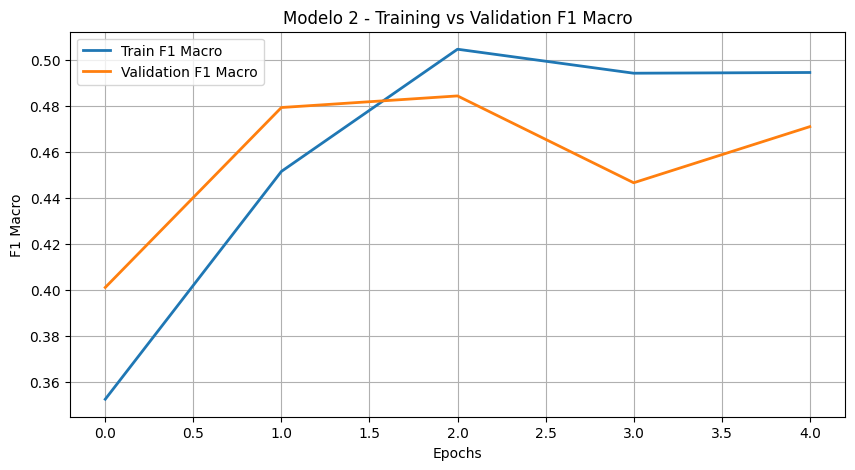

In [23]:
import matplotlib.pyplot as plt

# ==============================
# F1 MACRO MODELO 2
# ==============================

plt.figure(figsize=(10,5))

plt.plot(
    history2.history['f1_macro'],
    label='Train F1 Macro',
    linewidth=2
)

plt.plot(
    history2.history['val_f1_macro'],
    label='Validation F1 Macro',
    linewidth=2
)

plt.xlabel('Epochs')

plt.ylabel('F1 Macro')

plt.title('Modelo 2 - Training vs Validation F1 Macro')

plt.legend()

plt.grid(True)

plt.show()

In [24]:
print("\n===== COMPARACIÓN FINAL =====")

print(f"F1 Macro Modelo 1: {f1_model1:.4f}")

print(f"F1 Macro Modelo 2: {f1_model2:.4f}")

if f1_model1 > f1_model2:

    print("\nEl mejor modelo es el MODELO 1")

else:

    print("\nEl mejor modelo es el MODELO 2")


===== COMPARACIÓN FINAL =====
F1 Macro Modelo 1: 0.6600
F1 Macro Modelo 2: 0.6090

El mejor modelo es el MODELO 1


## CLASIFICACIÓN + PCA

In [57]:
#@title **code**  Classification from few components
Components = 7 #@param {type:"integer"}

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.decomposition import PCA


# Baseline classifier on raw features (no PCA).
est = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0)
est.fit(X_train, y_train)
y_est = est.predict(X_test)
print("X test", X_test.shape)
print(f1_score(y_test, y_est))

# PCA in a learning pipeline: fit ONLY on training data, then apply to test.
# Why not pca.fit(X) on all data?
# - PCA learns statistics (mean, variance, principal directions) from the data it sees.
# - If test samples influence those statistics, information from the test set
#   leaks into training (data leakage).
# - Metrics would be optimistically biased and would not reflect performance on
#   truly new data in production.
pca_1 = PCA(n_components=Components, whiten=True)

pca_1.fit(X_train_scaled)

X_pca_train = pca_1.fit_transform(X_train_scaled)
X_pca_test = pca_1.transform(X_test_scaled)

# Same classifier, now on PCA-reduced features.
est2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0)
est2.fit(X_pca_train, y_train)
y_est = est2.predict(X_pca_test)
print("X_test", X_pca_test.shape)
print(f1_score(y_test, y_est))

X test (885, 20)
0.5213849287169042
X_test (885, 7)
0.5060240963855421


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Eigenvalores
# =========================

print("Eigenvalores:")
print(pca_1.explained_variance_)

# =========================
# Varianza explicada
# =========================

print("\nVarianza explicada por componente:")
print(pca_1.explained_variance_ratio_)

# =========================
# Varianza acumulada
# =========================

print("\nVarianza acumulada:")
print(np.cumsum(pca_1.explained_variance_ratio_))

# =========================
# Eigenvectores / Componentes principales
# =========================

components_df = pd.DataFrame(
    pca_1.components_,
    columns=X_train.columns,
    index=[f'PC{i+1}' for i in range(pca_1.n_components_)]
)

print("\nEigenvectores (componentes principales):")
display(components_df)

Eigenvalores:
[2.67046619 2.01274556 1.8817089  1.62980879 1.57252949 1.46348756
 1.0994282 ]

Varianza explicada por componente:
[0.13348558 0.10060884 0.09405886 0.08146741 0.07860426 0.0731537
 0.05495588]

Varianza acumulada:
[0.13348558 0.23409442 0.32815328 0.40962069 0.48822495 0.56137865
 0.61633453]

Eigenvectores (componentes principales):


,Age at enrollment,Debtor,Gender,Application mode,Marital status,Curricular units 2nd sem (without evaluations),Mother's qualification,Curricular units 1st sem (without evaluations),Previous qualification,Inflation rate,Father's qualification,Unemployment rate,Nacionality,Educational special needs,International,Mother's occupation,Father's occupation,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),Course
PC1,0.439052,0.109638,0.082788,0.417453,0.296369,0.099237,0.234470,0.101972,0.236454,0.024029,0.198849,0.018149,-0.043832,-0.032770,-0.039212,0.114859,0.100878,0.407383,0.400009,0.028417
PC2,0.041512,0.062737,-0.052382,-0.050185,0.073621,-0.057512,0.231668,-0.079450,-0.102650,0.061733,0.218179,-0.180566,0.007088,-0.014531,-0.003051,0.584106,0.586000,-0.254569,-0.261816,0.087267
PC3,-0.088442,0.117031,0.041707,0.008772,-0.118590,0.086906,-0.211679,0.126889,0.035345,-0.065757,-0.244412,0.003610,0.584280,0.003781,0.588872,0.198183,0.188050,0.167908,0.163810,-0.104802
PC4,0.246054,0.016824,-0.026458,0.105331,0.270734,-0.308441,0.275416,-0.319690,-0.016314,0.045646,0.232084,0.019285,0.368602,-0.014312,0.358276,-0.266553,-0.271435,-0.233260,-0.239670,0.057382
PC5,0.060520,-0.061612,-0.102237,-0.095529,0.108962,0.583028,0.224324,0.584515,-0.203519,-0.049921,0.176225,-0.168304,0.096309,-0.042619,0.107547,-0.132448,-0.151377,-0.156138,-0.147551,0.128958
PC6,-0.177017,-0.226015,-0.275396,-0.332636,-0.122155,-0.172093,0.263774,-0.094305,-0.336605,0.198527,0.293865,-0.260927,0.055820,-0.026992,0.057477,-0.033004,-0.026610,0.369353,0.374227,-0.124561
PC7,0.115700,0.174930,0.629916,-0.047866,-0.008610,0.079572,0.048324,-0.005337,-0.210619,0.287551,-0.006869,-0.233216,-0.024140,0.045190,-0.036741,-0.035676,-0.046160,-0.056450,-0.055418,-0.594172


array([0.13348558, 0.10060884, 0.09405886, 0.08146741, 0.07860426,
       0.0731537 , 0.05495588])

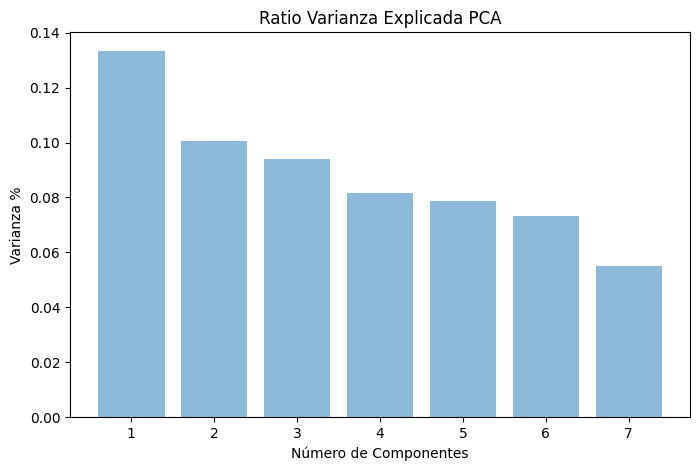

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    range(1, pca_1.n_components_ + 1),
    pca_1.explained_variance_ratio_,
    alpha=0.5,
    align='center',
    label='Varianza explicada'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza %')
plt.title('Ratio Varianza Explicada PCA')

pca_1.explained_variance_ratio_

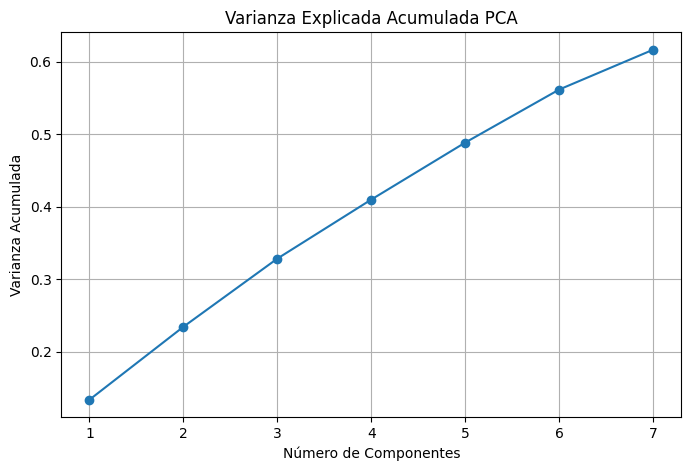

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, pca_1.n_components_ + 1),
    np.cumsum(pca_1.explained_variance_ratio_),
    marker='o'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada PCA')

plt.grid(True)
plt.show()

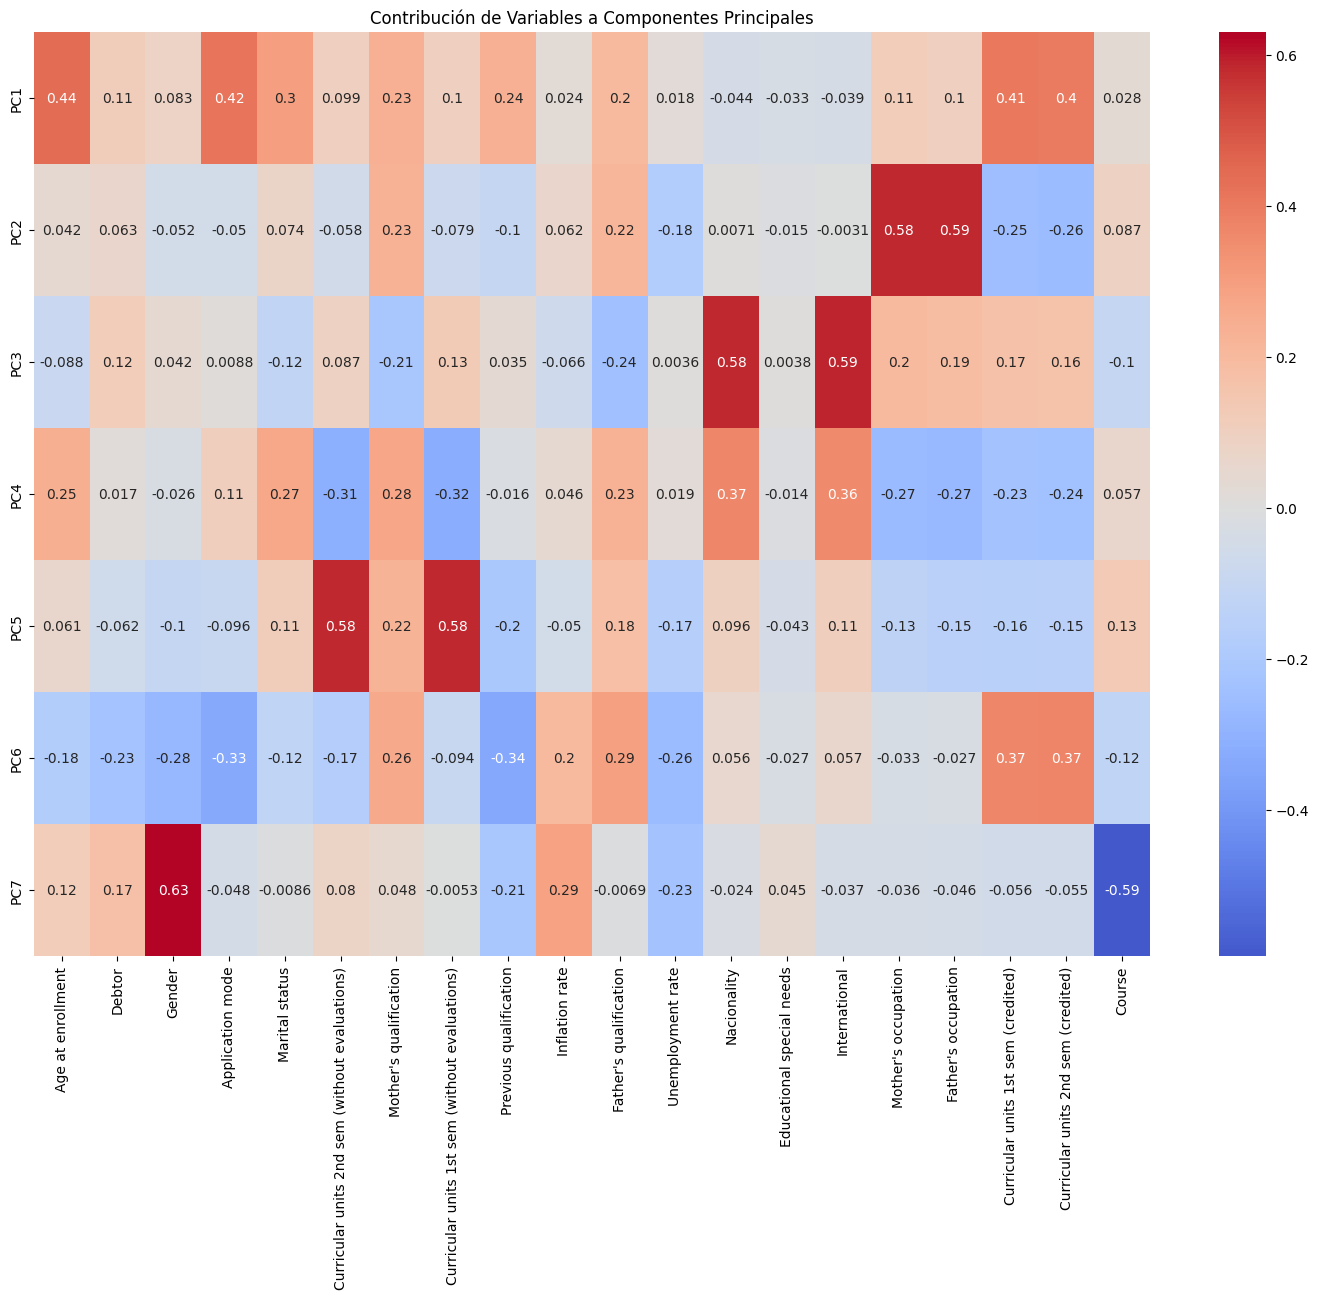

In [28]:
import seaborn as sns

plt.figure(figsize=(18,12))

sns.heatmap(
    components_df,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Contribución de Variables a Componentes Principales')
plt.show()

In [29]:
for i, component in enumerate(pca_1.components_):

    component_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Weight': component
    })

    component_df['AbsWeight'] = np.abs(component_df['Weight'])

    component_df = component_df.sort_values(
        by='AbsWeight',
        ascending=False
    )

    print(f"\nTop variables en PC{i+1}")
    display(component_df[['Feature', 'Weight']].head(10))


Top variables en PC1


,Feature,Weight
0,Age at enrollment,0.439052
3,Application mode,0.417453
17,Curricular units 1st sem (credited),0.407383
18,Curricular units 2nd sem (credited),0.400009
4,Marital status,0.296369
8,Previous qualification,0.236454
6,Mother's qualification,0.234470
10,Father's qualification,0.198849
15,Mother's occupation,0.114859
1,Debtor,0.109638



Top variables en PC2


,Feature,Weight
16,Father's occupation,0.586000
15,Mother's occupation,0.584106
18,Curricular units 2nd sem (credited),-0.261816
17,Curricular units 1st sem (credited),-0.254569
6,Mother's qualification,0.231668
10,Father's qualification,0.218179
11,Unemployment rate,-0.180566
8,Previous qualification,-0.102650
19,Course,0.087267
7,Curricular units 1st sem (without evaluations),-0.079450



Top variables en PC3


...

,Feature,Weight
7,Curricular units 1st sem (without evaluations),0.584515
5,Curricular units 2nd sem (without evaluations),0.583028
6,Mother's qualification,0.224324
8,Previous qualification,-0.203519
10,Father's qualification,0.176225
11,Unemployment rate,-0.168304
17,Curricular units 1st sem (credited),-0.156138
16,Father's occupation,-0.151377
18,Curricular units 2nd sem (credited),-0.147551
15,Mother's occupation,-0.132448



Top variables en PC6


,Feature,Weight
18,Curricular units 2nd sem (credited),0.374227
17,Curricular units 1st sem (credited),0.369353
8,Previous qualification,-0.336605
3,Application mode,-0.332636
10,Father's qualification,0.293865
2,Gender,-0.275396
6,Mother's qualification,0.263774
11,Unemployment rate,-0.260927
1,Debtor,-0.226015
9,Inflation rate,0.198527



Top variables en PC7


,Feature,Weight
2,Gender,0.629916
19,Course,-0.594172
9,Inflation rate,0.287551
11,Unemployment rate,-0.233216
8,Previous qualification,-0.210619
1,Debtor,0.174930
0,Age at enrollment,0.115700
5,Curricular units 2nd sem (without evaluations),0.079572
17,Curricular units 1st sem (credited),-0.056450
18,Curricular units 2nd sem (credited),-0.055418


## CLUSTERING

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

In [31]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

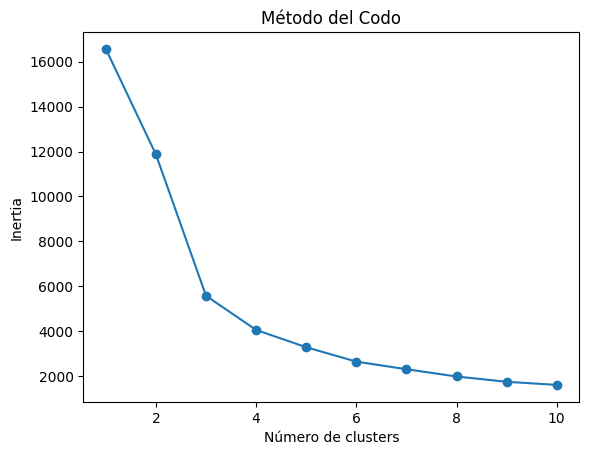

In [32]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Método del Codo')

plt.show()

In [33]:
from sklearn.metrics import silhouette_score
for k in range(2,11):

    km = KMeans(n_clusters=k, random_state=42)

    labels = km.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    print(k, score)

2 0.6922573996101242
3 0.5794230932872946
4 0.5350945738102086
5 0.40141868940021125
6 0.4231002342834168
7 0.42723315888846397
8 0.4275611750387499
9 0.4320159507058906
10 0.4298825629702341


In [65]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

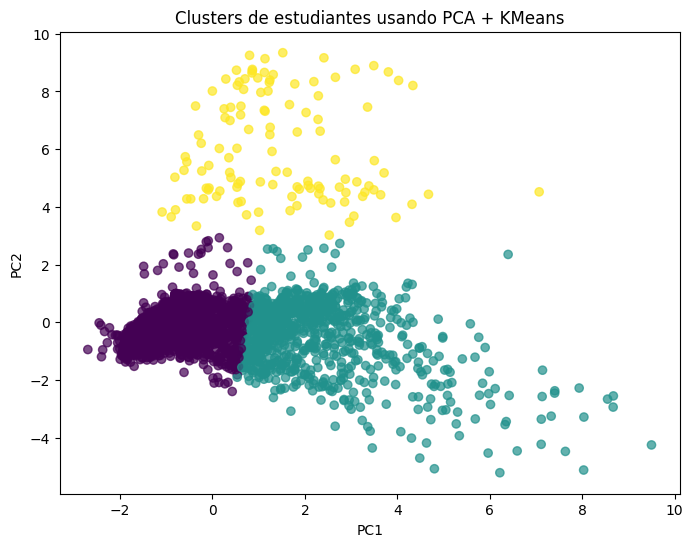

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('Clusters de estudiantes usando PCA + KMeans')

plt.show()

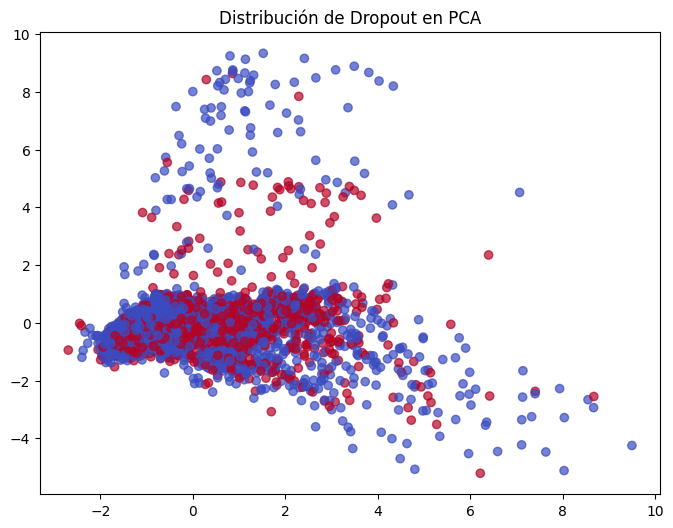

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.7
)

plt.title('Distribución de Dropout en PCA')

plt.show()

In [69]:
df_clusters = X_train.copy()

df_clusters['cluster'] = clusters

df_clusters['dropout'] = y_train.values

In [70]:
df_clusters.groupby('cluster').mean()

,Age at enrollment,Debtor,Gender,Application mode,Marital status,Curricular units 2nd sem (without evaluations),Mother's qualification,Curricular units 1st sem (without evaluations),Previous qualification,Inflation rate,...,Unemployment rate,Nacionality,Educational special needs,International,Mother's occupation,Father's occupation,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),Course,dropout
cluster,,,,,,,,,,,,,,,,,,,,,
0,20.225049,0.079843,0.308806,11.969080,1.014481,0.089628,16.743249,0.089237,1.750294,1.220665,...,11.522427,1.942074,0.014481,0.026223,5.900978,6.670450,0.053229,0.033659,8840.628963,0.277886
1,31.655491,0.206936,0.461272,37.470520,1.634682,0.324855,26.120231,0.280925,12.831214,1.192948,...,11.970983,1.329480,0.003468,0.013873,7.707514,6.789595,2.582659,2.005780,8945.119075,0.450867
2,25.403361,0.252101,0.394958,23.714286,1.277311,0.117647,23.193277,0.134454,5.436975,1.399160,...,10.157143,3.058824,0.008403,0.042017,139.285714,133.773109,0.563025,0.344538,9103.184874,0.310924


In [71]:
df_clusters.groupby('cluster')['dropout'].mean()

,dropout
cluster,
0,0.277886
1,0.450867
2,0.310924
